Đang sử dụng cấu hình tối ưu: cpu

--- BẤT ĐẦU VÒNG KHẢO SÁT 5-FOLD CROSS VALIDATION TỐI ƯU ---

--> Đang tính toán kiểm tra chéo cho mô hình: LSTM...
    Fold 1/5 hoàn thành | Acc: 94.7% | Recall: 88.8%
    Fold 2/5 hoàn thành | Acc: 92.8% | Recall: 87.0%
    Fold 3/5 hoàn thành | Acc: 94.3% | Recall: 85.0%
    Fold 4/5 hoàn thành | Acc: 93.6% | Recall: 84.8%
    Fold 5/5 hoàn thành | Acc: 94.1% | Recall: 83.0%

--> Đang tính toán kiểm tra chéo cho mô hình: GRU...
    Fold 1/5 hoàn thành | Acc: 92.7% | Recall: 82.4%
    Fold 2/5 hoàn thành | Acc: 93.1% | Recall: 83.3%
    Fold 3/5 hoàn thành | Acc: 94.3% | Recall: 86.6%
    Fold 4/5 hoàn thành | Acc: 92.8% | Recall: 83.2%
    Fold 5/5 hoàn thành | Acc: 94.4% | Recall: 88.0%

--> Đang tính toán kiểm tra chéo cho mô hình: CNN-1D (TCN)...
    Fold 1/5 hoàn thành | Acc: 89.8% | Recall: 76.3%
    Fold 2/5 hoàn thành | Acc: 87.6% | Recall: 67.5%
    Fold 3/5 hoàn thành | Acc: 88.8% | Recall: 68.1%
    Fold 4/5 hoàn thành | Acc: 90.0% | Reca

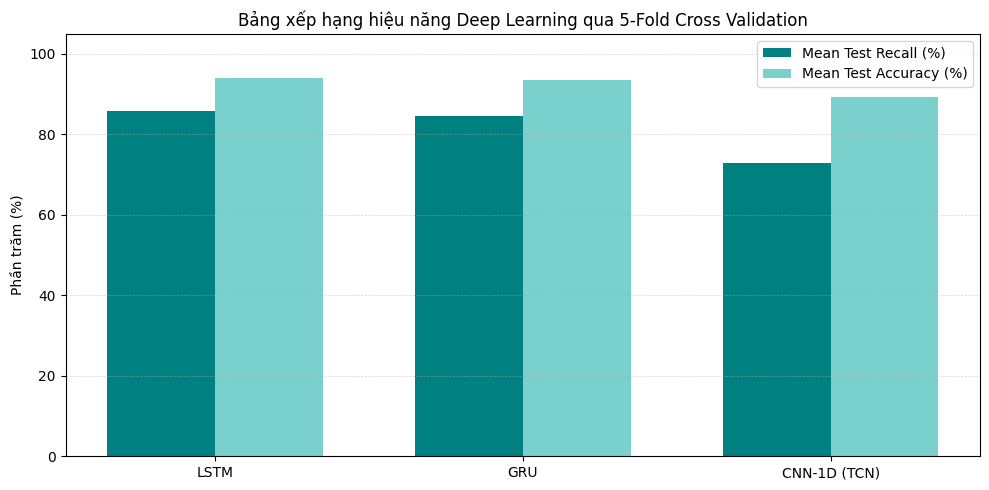

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, accuracy_score, f1_score
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng cấu hình tối ưu: {device}")

# -------------------------------------------------------------
# 1. ĐỊNH NGHĨA HÀM FOCAL LOSS CHỐNG LỆCH NHÃN
# -------------------------------------------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha  # Trọng số ưu tiên nhãn ít (Fall)
        self.gamma = gamma  # Hệ số tập trung vào các ca khó
        self.reduction = reduction

    def forward(self, inputs, targets):
        BCE_loss = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss) # Xác suất dự đoán đúng
        focal_loss = self.alpha * (1 - pt)**self.gamma * BCE_loss

        if self.reduction == 'mean': return focal_loss.mean()
        elif self.reduction == 'sum': return focal_loss.sum()
        return focal_loss

# -------------------------------------------------------------
# 2. DATASET NÂNG CAO: TÍNH VẬN TỐC, GIA TỐC VÀ AUGMENTATION
# -------------------------------------------------------------
class OptimizedSkeletonDataset(Dataset):
    def __init__(self, sequences, labels, max_len=16, is_train=False):
        self.sequences = []
        self.labels = labels
        self.is_train = is_train
        self.max_len = max_len

        for idx, seq in enumerate(sequences):
            seq = np.array(seq)

            # --- CẢI TIẾN 1: FEATURE ENGINEERING (Tính Vận tốc & Gia tốc) ---
            raw_flat = seq.reshape(seq.shape[0], -1)
            velocity = np.diff(raw_flat, axis=0, append=raw_flat[-1:])
            acceleration = np.diff(velocity, axis=0, append=velocity[-1:])
            enriched_seq = np.hstack((raw_flat, velocity, acceleration))

            # --- CẢI TIẾN 2: ĐỒNG BỘ ĐỘ DÀI VỚI CỬA SỔ RÚT GỌN (16 FRAMES) ---
            if len(enriched_seq) >= self.max_len:
                seq_padded = enriched_seq[:self.max_len]
            else:
                padding = np.zeros((self.max_len - len(enriched_seq), 102))
                seq_padded = np.vstack((enriched_seq, padding))

            # Đẩy chuỗi gốc vào trước
            self.sequences.append(seq_padded)

            # --- CẢI TIẾN 3: DATA AUGMENTATION ---
            if self.is_train and labels[idx] == 1:
                # Kỹ thuật Jittering: Thêm nhiễu trắng nhỏ vào các ca Fall để nhân đôi data ngã
                noise = np.random.normal(0, 0.02, seq_padded.shape)
                self.sequences.append(seq_padded + noise)

        # Đồng bộ lại danh sách nhãn tương ứng cho các chuỗi đã sinh ra
        if self.is_train:
            augmented_labels = []
            for idx in range(len(sequences)):
                augmented_labels.append(labels[idx])
                if labels[idx] == 1:
                    augmented_labels.append(labels[idx])
            self.labels = np.array(augmented_labels, dtype=np.float32)
        else:
            self.labels = np.array(self.labels, dtype=np.float32)

        self.sequences = np.array(self.sequences, dtype=np.float32)

    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return torch.tensor(self.sequences[idx]), torch.tensor(self.labels[idx])

# -------------------------------------------------------------
# 3. CÁC MÔ HÌNH DEEP LEARNING CẬP NHẬT INPUT SIZE = 102
# -------------------------------------------------------------
class LSTMModel(nn.Module):
    def __init__(self, input_size=102, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=2, batch_first=True, dropout=0.3)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class GRUModel(nn.Module):
    def __init__(self, input_size=102, hidden_size=64):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers=2, batch_first=True, dropout=0.3)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

class CNN1DModel(nn.Module):
    def __init__(self, input_size=102, hidden_size=64):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=input_size, out_channels=hidden_size, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.relu(self.conv1(x))
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

# -------------------------------------------------------------
# 4. HÀM HUẤN LUYỆN VÀ ĐÁNH GIÁ TRÊN TỪNG FOLD DỮ LIỆU
# -------------------------------------------------------------
def train_and_eval_deep_model(model_class, loaders, criterion):
    train_loader, test_loader = loaders
    model = model_class().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

    for epoch in range(40):
        model.train()
        for seqs, labels in train_loader:
            seqs, labels = seqs.to(device), labels.to(device).unsqueeze(1)
            optimizer.zero_grad()
            loss = criterion(model(seqs), labels)
            loss.backward()
            optimizer.step()

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for seqs, labels in test_loader:
            seqs, labels = seqs.to(device), labels.to(device).unsqueeze(1)
            outputs = model(seqs)
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_labels, all_preds = np.array(all_labels), np.array(all_preds)
    acc = accuracy_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    return acc, recall, f1

# -------------------------------------------------------------
# 5. LUỒNG ĐIỀU KHIỂN CHẠY 5-FOLD CROSS VALIDATION
# -------------------------------------------------------------
def main():
    X = np.load('./data_processed/sequences.npy', allow_pickle=True)
    y = np.load('./data_processed/labels.npy')

    # Chia tách dữ liệu theo cơ chế 5-Fold để phá vỡ thế trùng lặp điểm số
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    deep_models_pool = {
        "LSTM": LSTMModel,
        "GRU": GRUModel,
        "CNN-1D (TCN)": CNN1DModel
    }

    criterion = FocalLoss(alpha=0.75, gamma=2.0)
    final_results = {}

    print("\n--- BẤT ĐẦU VÒNG KHẢO SÁT 5-FOLD CROSS VALIDATION TỐI ƯU ---")

    for name, model_class in deep_models_pool.items():
        fold_accs, fold_recalls, fold_f1s = [], [], []
        print(f"\n--> Đang tính toán kiểm tra chéo cho mô hình: {name}...")

        for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            train_dataset = OptimizedSkeletonDataset(X_train, y_train, max_len=16, is_train=True)
            test_dataset = OptimizedSkeletonDataset(X_test, y_test, max_len=16, is_train=False)

            train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
            test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
            loaders = (train_loader, test_loader)

            acc, rec, f1 = train_and_eval_deep_model(model_class, loaders, criterion)
            fold_accs.append(acc)
            fold_recalls.append(rec)
            fold_f1s.append(f1)
            print(f"    Fold {fold+1}/5 hoàn thành | Acc: {acc*100:.1f}% | Recall: {rec*100:.1f}%")

        # Lưu lại điểm trung bình cộng của cả 5 lần hoán vị tập dữ liệu
        final_results[name] = {
            "Accuracy": np.mean(fold_accs) * 100,
            "Recall": np.mean(fold_recalls) * 100,
            "F1-Score": np.mean(fold_f1s) * 100
        }

    # IN BẢNG XẾP HẠNG KHÁCH QUAN CUỐI CÙNG
    print("\n================ BẢNG KẾT QUẢ ĐÁNH GIÁ 5-FOLD TOÀN DIỆN ================")
    for model_name, metrics in final_results.items():
        print(f"--> MODEL {model_name.ljust(12)}: Mean Accuracy = {metrics['Accuracy']:.2f}% | Mean Recall = {metrics['Recall']:.2f}% | Mean F1 = {metrics['F1-Score']:.2f}%")
    print("=========================================================================")

    # -------------------------------------------------------------
    # 6. TỰ ĐỘNG XUẤT BIỂU ĐỒ SO SÁNH PHỤC VỤ BÁO CÁO GI THUB
    # -------------------------------------------------------------
    model_labels = list(final_results.keys())
    mean_recalls = [final_results[m]["Recall"] for m in model_labels]
    mean_accuracies = [final_results[m]["Accuracy"] for m in model_labels]

    x = np.arange(len(model_labels))
    width = 0.35

    plt.figure(figsize=(10, 5))
    plt.bar(x - width/2, mean_recalls, width, label='Mean Test Recall (%)', color='teal')
    plt.bar(x + width/2, mean_accuracies, width, label='Mean Test Accuracy (%)', color='lightseagreen', alpha=0.6)

    plt.ylabel('Phần trăm (%)')
    plt.title('Bảng xếp hạng hiệu năng Deep Learning qua 5-Fold Cross Validation')
    plt.xticks(x, model_labels)
    plt.ylim(0, 105)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()

    os.makedirs("./plots", exist_ok=True)
    plt.savefig('./plots/deep_learning_comparison.png', dpi=300)
    print("\n[Thành công] Đã cập nhật biểu đồ phân hóa tại: './plots/deep_learning_comparison.png'")

if __name__ == "__main__":
    main()

In [2]:
import os
import copy
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    recall_score, accuracy_score, f1_score,
    confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng cấu hình: {device}")

# =============================================================
# 1. FOCAL LOSS CHUẨN (ĐÃ SỬA LỖI ALPHA)
# =============================================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce)

        # Tính alpha_t động cho từng mẫu dựa theo nhãn (0 hoặc 1)
        alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)

        focal = alpha_t * (1 - pt) ** self.gamma * bce
        return focal.mean() if self.reduction == 'mean' else focal

# =============================================================
# 2. DATASET (SỬ DỤNG PRE-PADDING BẰNG REPLICATE)
# =============================================================
class OptimizedSkeletonDataset(Dataset):
    def __init__(self, sequences, labels, max_len=16, is_train=False):
        self.is_train = is_train
        self.max_len = max_len
        self.labels = np.array(labels, dtype=np.float32)
        self.sequences = []

        for seq in sequences:
            seq = np.array(seq, dtype=np.float32)
            raw_flat = seq.reshape(seq.shape[0], -1)  # (T, F)

            T, F = raw_flat.shape
            if T >= max_len:
                padded_raw = raw_flat[:max_len]
            else:
                # Dùng Pre-padding và lặp lại frame đầu tiên
                # (để tránh tạo ra đột biến giả về vận tốc/gia tốc tại biên đệm)
                padding = np.tile(raw_flat[0], (max_len - T, 1))
                padded_raw = np.vstack((padding, raw_flat))

            # Tính đạo hàm động học
            velocity = np.diff(padded_raw, axis=0, append=padded_raw[-1:])
            acceleration = np.diff(velocity, axis=0, append=velocity[-1:])
            enriched = np.hstack((padded_raw, velocity, acceleration))  # (max_len, 3*F)

            self.sequences.append(enriched.astype(np.float32))

        self.sequences = np.array(self.sequences, dtype=np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        seq = self.sequences[idx].copy()

        if self.is_train and self.labels[idx] == 1 and random.random() < 0.5:
            seq = seq + np.random.normal(0, 0.02, seq.shape).astype(np.float32)

        return torch.tensor(seq), torch.tensor(self.labels[idx])

# =============================================================
# 3. MÔ HÌNH LSTM
# =============================================================
class DynamicLSTMModel(nn.Module):
    def __init__(self, input_size=102, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=0.3 if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        # Vì đã dùng pre-padding, bước thời gian cuối cùng chứa đầy đủ thông tin thực tế nhất
        return self.fc(out[:, -1, :])

# =============================================================
# 4. ĐÁNH GIÁ
# =============================================================
def evaluate_model(model, dataloader, criterion, threshold=0.5):
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for seqs, labels in dataloader:
            seqs, labels = seqs.to(device), labels.to(device).unsqueeze(1)
            outputs = model(seqs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs >= threshold).float()
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)
    all_probs  = np.array(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    f1  = f1_score(all_labels, all_preds, zero_division=0)
    avg_loss = total_loss / len(dataloader)

    return avg_loss, acc, rec, f1, all_labels, all_preds, all_probs

def find_optimal_threshold(all_labels, all_probs):
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    idx = np.argmax(tpr - fpr)
    return float(thresholds[idx])

# =============================================================
# 5. GRID SEARCH
# =============================================================
def run_grid_search(train_loader, val_loader, criterion, grid_space, probe_epochs=35):
    best_recall = -1.0
    best_f1     = -1.0
    best_config = None

    print("\n==== GIAI ĐOẠN 1: GRID SEARCH (LSTM) ====")
    for h_size in grid_space['hidden_size']:
        for n_layers in grid_space['num_layers']:
            for lr_rate in grid_space['lr']:
                config = {'hidden_size': h_size, 'num_layers': n_layers, 'lr': lr_rate}
                set_seed(42)
                model = DynamicLSTMModel(hidden_size=h_size, num_layers=n_layers).to(device)
                optimizer = torch.optim.AdamW(model.parameters(), lr=lr_rate, weight_decay=0.01)

                best_probe_score = -1.0
                best_probe_state = None
                no_improve = 0
                patience = 7

                for epoch in range(probe_epochs):
                    model.train()
                    for seqs, labels in train_loader:
                        seqs, labels = seqs.to(device), labels.to(device).unsqueeze(1)
                        optimizer.zero_grad()
                        criterion(model(seqs), labels).backward()
                        optimizer.step()

                    _, _, val_rec, val_f1, _, _, _ = evaluate_model(model, val_loader, criterion)
                    probe_score = 0.7 * val_rec + 0.3 * val_f1

                    if probe_score > best_probe_score:
                        best_probe_score = probe_score
                        best_probe_state = copy.deepcopy(model.state_dict())
                        no_improve = 0
                    else:
                        no_improve += 1
                    if no_improve >= patience:
                        break

                # Load lại trạng thái tốt nhất tìm được trong quá trình probe
                if best_probe_state is not None:
                    model.load_state_dict(best_probe_state)

                _, _, val_rec, val_f1, _, _, _ = evaluate_model(model, val_loader, criterion)
                print(f"  H={h_size} L={n_layers} LR={lr_rate} "
                      f"| Val Recall: {val_rec*100:.1f}% | Val F1: {val_f1*100:.1f}%")

                if val_rec > best_recall or (val_rec == best_recall and val_f1 > best_f1):
                    best_recall = val_rec
                    best_f1     = val_f1
                    best_config = config

    print(f"\n[*] Config tối ưu: {best_config}")
    return best_config

def train_final_model(train_loader, val_loader, best_config, criterion, epochs=50):
    model = DynamicLSTMModel(
        hidden_size=best_config['hidden_size'],
        num_layers=best_config['num_layers']
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=best_config['lr'], weight_decay=0.01
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=6
    )

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    best_score      = -1.0
    best_model_state = None
    patience        = 12
    no_improve      = 0

    print("\n==== GIAI ĐOẠN 2: HUẤN LUYỆN CHI TIẾT (LSTM) ====")

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for seqs, labels in train_loader:
            seqs, labels = seqs.to(device), labels.to(device).unsqueeze(1)
            optimizer.zero_grad()
            outputs = model(seqs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss    += loss.item()
            preds          = (torch.sigmoid(outputs) >= 0.5).float()
            train_correct += (preds == labels).sum().item()
            train_total   += labels.size(0)

        epoch_train_loss = train_loss / len(train_loader)
        epoch_train_acc  = train_correct / train_total

        epoch_val_loss, epoch_val_acc, epoch_val_rec, epoch_val_f1, _, _, _ = \
            evaluate_model(model, val_loader, criterion)

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)

        score = 0.7 * epoch_val_rec + 0.3 * epoch_val_f1
        scheduler.step(score)

        print(f"Epoch [{epoch+1:02d}/{epochs}] "
              f"TrainLoss: {epoch_train_loss:.4f} TrainAcc: {epoch_train_acc*100:.1f}% | "
              f"ValLoss: {epoch_val_loss:.4f} ValAcc: {epoch_val_acc*100:.1f}% "
              f"ValRecall: {epoch_val_rec*100:.1f}% ValF1: {epoch_val_f1*100:.1f}%")

        if score > best_score:
            best_score       = score
            best_model_state = copy.deepcopy(model.state_dict())
            no_improve       = 0
            print(f"  ==> Cải thiện! Score={best_score:.4f} — đã lưu trạng thái model.")
        else:
            no_improve += 1

        if no_improve >= patience:
            print(f"  [Early Stop] Không cải thiện sau {patience} epoch. Dừng sớm.")
            break

    if best_model_state is None:
        best_model_state = copy.deepcopy(model.state_dict())

    return model, best_model_state, history

# =============================================================
# 6. MAIN
# =============================================================
def main():
    X = np.load('./data_processed/imvia_sequences.npy', allow_pickle=True)
    y = np.load('./data_processed/imvia_labels.npy')

    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=0.15, random_state=42, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.176, random_state=42, stratify=y_train_val
    )

    def seed_worker(worker_id):
        np.random.seed(42 + worker_id)
        random.seed(42 + worker_id)

    g = torch.Generator()
    g.manual_seed(42)

    train_loader = DataLoader(
        OptimizedSkeletonDataset(X_train, y_train, max_len=16, is_train=True),
        batch_size=8, shuffle=True,
        worker_init_fn=seed_worker, generator=g
    )
    val_loader = DataLoader(
        OptimizedSkeletonDataset(X_val, y_val, max_len=16),
        batch_size=8, shuffle=False
    )
    test_loader = DataLoader(
        OptimizedSkeletonDataset(X_test, y_test, max_len=16),
        batch_size=8, shuffle=False
    )

    criterion = FocalLoss(alpha=0.75, gamma=2.0)

    grid_space = {
        'hidden_size': [32, 64],
        'num_layers':  [1, 2],
        'lr':          [0.001, 0.005]
    }

    # --- Grid Search ---
    best_config = run_grid_search(train_loader, val_loader, criterion, grid_space, probe_epochs=35)

    # --- Huấn luyện chi tiết ---
    final_model, best_model_state, history = train_final_model(
        train_loader, val_loader, best_config, criterion, epochs=50
    )

    final_model.load_state_dict(best_model_state)
    _, _, _, _, val_true, _, val_probs = evaluate_model(final_model, val_loader, criterion)
    optimal_threshold = find_optimal_threshold(val_true, val_probs)
    print(f"\n[*] Threshold tối ưu (Youden Index trên Val): {optimal_threshold:.4f}")

    # --- Đánh giá trên Test set với threshold tối ưu ---
    test_loss, test_acc, test_rec, test_f1, true_labels, pred_labels, _ = \
        evaluate_model(final_model, test_loader, criterion, threshold=optimal_threshold)

    print("\n==== KẾT QUẢ CUỐI CÙNG TRÊN TẬP TEST (LSTM OPTIMIZED) ====")
    print(f"Threshold sử dụng         : {optimal_threshold:.4f}")
    print(f"Accuracy                  : {test_acc*100:.2f}%")
    print(f"Recall (nhạy ca té ngã)   : {test_rec*100:.2f}%")
    print(f"F1-Score                  : {test_f1*100:.2f}%")
    print("=" * 60)

    # --- Lưu model & config (LƯU BẰNG ĐUÔI .NPY NHƯ CŨ) ---
    os.makedirs("./models", exist_ok=True)
    np.save('./models/best_lstm_config.npy', {**best_config, 'threshold': optimal_threshold})
    torch.save(best_model_state, './models/best_lstm_fall_model.pth')
    print("[OK] Đã lưu model tại './models/best_lstm_fall_model.pth'")

    # --- Xuất đồ thị ---
    os.makedirs("./plots", exist_ok=True)
    epochs_ran = len(history['train_loss'])

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs_ran + 1), history['train_loss'], label='Train Loss', color='blue')
    plt.plot(range(1, epochs_ran + 1), history['val_loss'],   label='Val Loss',   color='orange', linestyle='--')
    plt.title('Loss History (LSTM Optimized)')
    plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs_ran + 1), history['train_acc'], label='Train Accuracy', color='green')
    plt.plot(range(1, epochs_ran + 1), history['val_acc'],   label='Val Accuracy',   color='red',  linestyle='--')
    plt.title('Accuracy History (LSTM Optimized)')
    plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
    plt.tight_layout()
    plt.savefig('./plots/lstm_training_history.png', dpi=300); plt.close()
    print("[OK] Đã xuất biểu đồ học tập.")

    cm = confusion_matrix(true_labels, pred_labels)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='Oranges',
        xticklabels=['ADL (Bình thường)', 'Fall (Té ngã)'],
        yticklabels=['ADL (Bình thường)', 'Fall (Té ngã)']
    )
    plt.title(f'Normalized Confusion Matrix (LSTM, threshold={optimal_threshold:.2f})')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('./plots/lstm_normalized_confusion_matrix.png', dpi=300); plt.close()
    print("[OK] Đã xuất Confusion Matrix.")

if __name__ == "__main__":
    main()

Đang sử dụng cấu hình: cpu

==== GIAI ĐOẠN 1: GRID SEARCH (LSTM) ====
  H=32 L=1 LR=0.001 | Val Recall: 90.5% | Val F1: 77.2%
  H=32 L=1 LR=0.005 | Val Recall: 92.9% | Val F1: 78.7%
  H=32 L=2 LR=0.001 | Val Recall: 91.3% | Val F1: 81.0%
  H=32 L=2 LR=0.005 | Val Recall: 94.3% | Val F1: 83.1%
  H=64 L=1 LR=0.001 | Val Recall: 92.4% | Val F1: 81.7%
  H=64 L=1 LR=0.005 | Val Recall: 91.0% | Val F1: 76.0%
  H=64 L=2 LR=0.001 | Val Recall: 94.0% | Val F1: 80.1%
  H=64 L=2 LR=0.005 | Val Recall: 92.4% | Val F1: 79.6%

[*] Config tối ưu: {'hidden_size': 32, 'num_layers': 2, 'lr': 0.005}

==== GIAI ĐOẠN 2: HUẤN LUYỆN CHI TIẾT (LSTM) ====
Epoch [01/50] TrainLoss: 0.0466 TrainAcc: 79.6% | ValLoss: 0.0436 ValAcc: 80.3% ValRecall: 83.4% ValF1: 67.4%
  ==> Cải thiện! Score=0.7862 — đã lưu trạng thái model.
Epoch [02/50] TrainLoss: 0.0419 TrainAcc: 81.4% | ValLoss: 0.0398 ValAcc: 80.3% ValRecall: 86.7% ValF1: 68.2%
  ==> Cải thiện! Score=0.8115 — đã lưu trạng thái model.
Epoch [03/50] TrainLoss: 0.